In [1]:
from google.colab import files

uploaded = files.upload()

Saving normalized.csv to normalized.csv


Balanced Train set: 1122 | Val set: 54 | Test set (Unseen): 95


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/7 -> Train Loss: 2.8222, Val Loss: 2.5118
Epoch 2/7 -> Train Loss: 1.8086, Val Loss: 1.8300
Epoch 3/7 -> Train Loss: 1.0622, Val Loss: 1.2869
Epoch 4/7 -> Train Loss: 0.6105, Val Loss: 0.8309
Epoch 5/7 -> Train Loss: 0.3640, Val Loss: 0.6688
Epoch 6/7 -> Train Loss: 0.2254, Val Loss: 0.5648
Epoch 7/7 -> Train Loss: 0.1565, Val Loss: 0.5342

TASK 1: AUTOIMMUNE DETECTION
Binary Accuracy: 0.9263
                precision    recall  f1-score   support

Non-Autoimmune       0.73      0.94      0.82        17
    Autoimmune       0.99      0.92      0.95        78

      accuracy                           0.93        95
     macro avg       0.86      0.93      0.89        95
  weighted avg       0.94      0.93      0.93        95


TASK 2: SPECIFIC DISEASE PREDICTION
Disease Accuracy: 0.9053
Macro F1-Score: 0.8963

Final Disease Classification Report:
                             precision    recall  f1-score   support

                     Anemia       0.43      1.00      0.60      

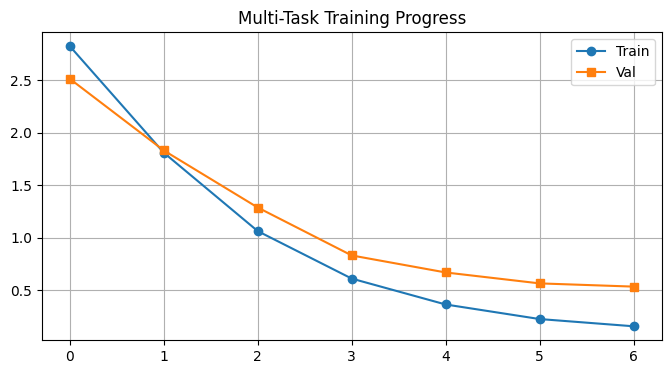

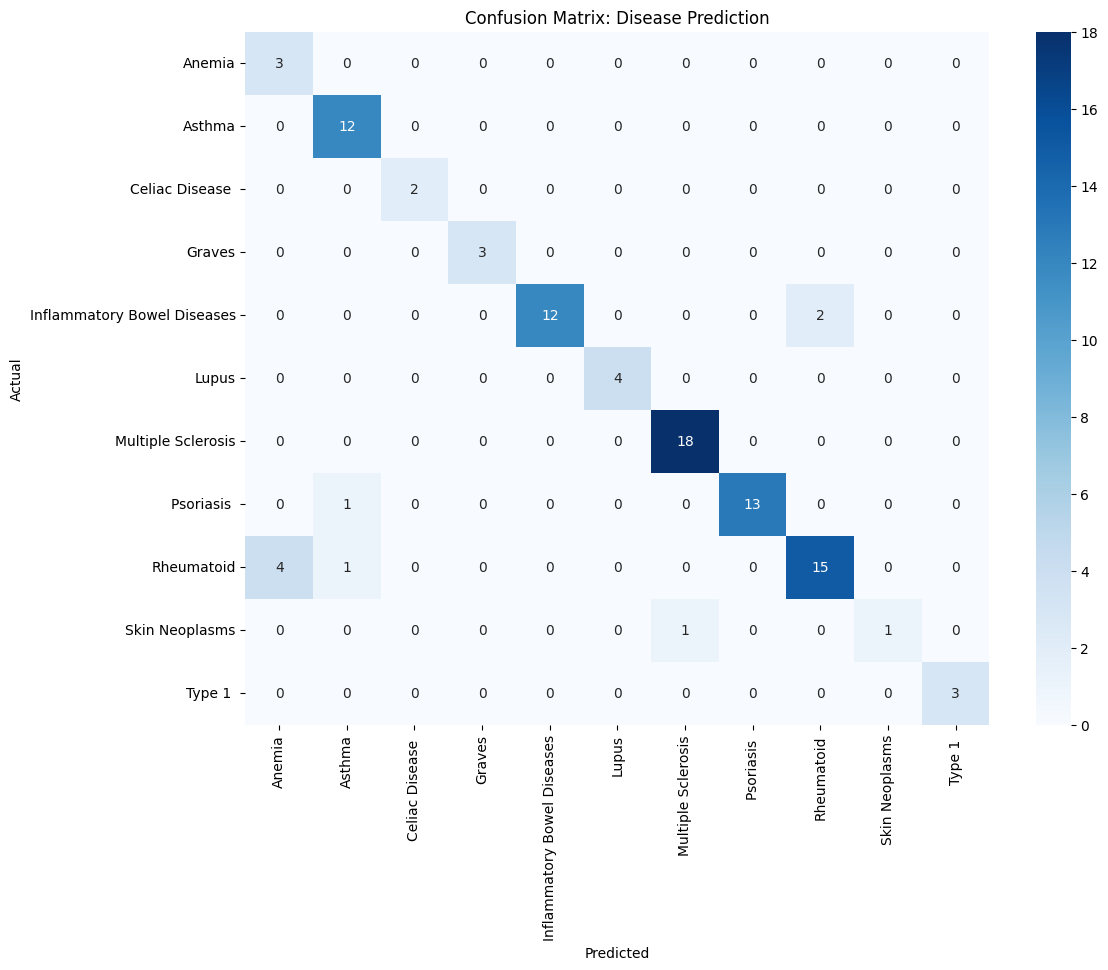

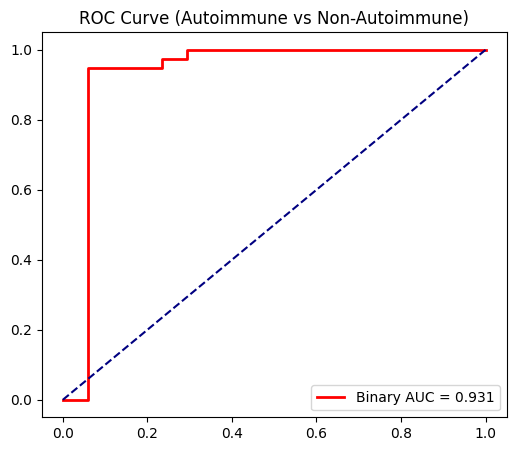

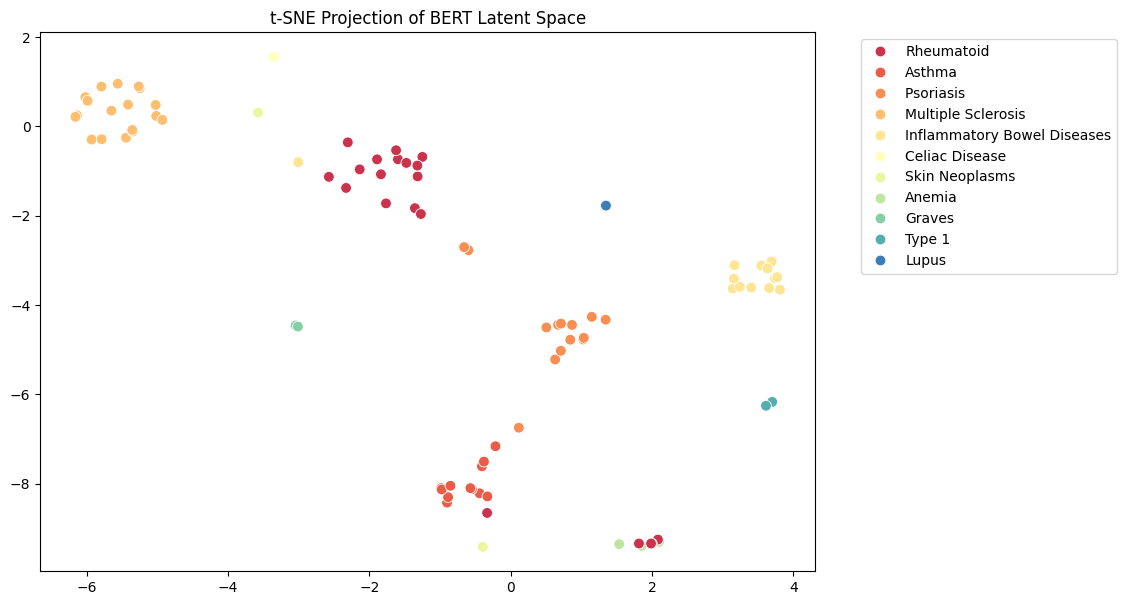

In [ ]:
"""
AutoimmuneTrans-miR: Paper-Ready Final Code
Tasks: 1. Autoimmune vs Non-Autoimmune (Binary)
       2. Specific Disease Prediction (Multi-class)
Features: Leakage-free split, Oversampling on Train-only, GPU support, t-SNE, Confusion Matrix, Advanced Metrics.
"""

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_curve, auc, precision_recall_curve, f1_score)
from torch.utils.data import Dataset, DataLoader
from sklearn.utils import resample
from sklearn.manifold import TSNE


# 1. Data Loading & Cleaning

df = pd.read_csv("normalized.csv", encoding='utf-8-sig')
df.columns = df.columns.str.strip()

if 'Disease_name' not in df.columns:
    df.rename(columns={df.columns[0]: 'Disease_name'}, inplace=True)


counts = df['Disease_name'].value_counts()
df = df[df['Disease_name'].isin(counts[counts >= 5].index)].reset_index(drop=True)

# Label encoding & Feature creation
le = LabelEncoder()
df["disease_id"] = le.fit_transform(df["Disease_name"])
num_diseases = len(le.classes_)
df["text"] = df["miRNA"].astype(str) + " [SEP] " + df["sequence"].astype(str) + " [SEP] " + df["genes"].astype(str)


# 2. STRATEGIC SPLIT (Preventing Data Leakage)

train_val_df, test_df = train_test_split(df, test_size=0.15, random_state=42, stratify=df["disease_id"])
train_df, val_df = train_test_split(train_val_df, test_size=0.1, random_state=42, stratify=train_val_df["disease_id"])


# 3. OVERSAMPLING (Only on Train Data)

max_size = train_df['Disease_name'].value_counts().max()
lst = [train_df[train_df['Disease_name'] == i] for i in train_df['Disease_name'].unique()]
train_df_balanced = pd.concat([resample(l, replace=True, n_samples=max_size, random_state=42) for l in lst])
train_df = train_df_balanced.sample(frac=1).reset_index(drop=True)

print(f"Balanced Train set: {len(train_df)} | Val set: {len(val_df)} | Test set (Unseen): {len(test_df)}")


# 4. Tokenization & Dataset

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def encode_data(dataframe):
    encodings = tokenizer(dataframe["text"].tolist(), truncation=True, padding=True, max_length=128, return_tensors='pt')
    return encodings["input_ids"], encodings["attention_mask"], \
           torch.tensor(dataframe["label"].values, dtype=torch.float), \
           torch.tensor(dataframe["disease_id"].values, dtype=torch.long)

train_ids, train_masks, train_bin, train_dis = encode_data(train_df)
val_ids, val_masks, val_bin, val_dis = encode_data(val_df)
test_ids, test_masks, test_bin, test_dis = encode_data(test_df)

class MiRNADataset(Dataset):
    def __init__(self, ids, masks, bin_labels, dis_labels):
        self.ids, self.masks, self.bin_labels, self.dis_labels = ids, masks, bin_labels, dis_labels
    def __len__(self): return len(self.bin_labels)
    def __getitem__(self, idx):
        return {"input_ids": self.ids[idx], "attention_mask": self.masks[idx],
                "binary": self.bin_labels[idx], "disease": self.dis_labels[idx]}

train_loader = DataLoader(MiRNADataset(train_ids, train_masks, train_bin, train_dis), batch_size=16, shuffle=True)
val_loader = DataLoader(MiRNADataset(val_ids, val_masks, val_bin, val_dis), batch_size=16)
test_loader = DataLoader(MiRNADataset(test_ids, test_masks, test_bin, test_dis), batch_size=16)


# 5. Model Architecture

class AutoimmuneTransMiR(nn.Module):
    def __init__(self, num_disease):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.drop = nn.Dropout(0.3)
        self.out_bin = nn.Linear(768, 1)
        self.out_dis = nn.Linear(768, num_disease)
    def forward(self, ids, mask):
        out = self.bert(ids, attention_mask=mask).pooler_output
        hidden_feats = out
        out = self.drop(out)
        return self.out_bin(out), self.out_dis(out), hidden_feats

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoimmuneTransMiR(num_diseases).to(device)


# 6. Training with Validation

optimizer = AdamW(model.parameters(), lr=3e-5, weight_decay=0.01)
epochs = 7
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)
criterion_bin = nn.BCEWithLogitsLoss()
criterion_dis = nn.CrossEntropyLoss()

train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        b_out, d_out, _ = model(batch["input_ids"].to(device), batch["attention_mask"].to(device))
        loss = criterion_bin(b_out.squeeze(), batch["binary"].to(device)) + \
               criterion_dis(d_out, batch["disease"].to(device))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            b_out, d_out, _ = model(batch["input_ids"].to(device), batch["attention_mask"].to(device))
            v_loss = criterion_bin(b_out.squeeze(), batch["binary"].to(device)) + \
                     criterion_dis(d_out, batch["disease"].to(device))
            total_val_loss += v_loss.item()
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{epochs} -> Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")


# 7. IMPROVED PREDICTION & EVALUATION PART

model.eval()
all_embeddings = []
bin_true, bin_probs, bin_preds = [], [], []
dis_true, dis_probs, dis_preds = [], [], []

with torch.no_grad():
    for batch in test_loader:
        b_out, d_out, feats = model(batch["input_ids"].to(device), batch["attention_mask"].to(device))

        # Collect for Binary Task
        prob_bin = torch.sigmoid(b_out).cpu().numpy()
        bin_probs.extend(prob_bin)
        bin_preds.extend((prob_bin > 0.5).astype(int))
        bin_true.extend(batch["binary"].numpy())

        # Collect for Disease Task
        prob_dis = torch.softmax(d_out, dim=1).cpu().numpy()
        dis_probs.extend(prob_dis)
        dis_preds.extend(torch.argmax(d_out, dim=1).cpu().numpy())
        dis_true.extend(batch["disease"].numpy())

        # Collect for t-SNE
        all_embeddings.append(feats.cpu().numpy())

# TASK 1: BINARY EVALUATION
print("\n" + "="*30)
print("TASK 1: AUTOIMMUNE DETECTION")
print("="*30)
print(f"Binary Accuracy: {accuracy_score(bin_true, bin_preds):.4f}")
print(classification_report(bin_true, bin_preds, target_names=['Non-Autoimmune', 'Autoimmune']))

# TASK 2: DISEASE EVALUATION
print("\n" + "="*30)
print("TASK 2: SPECIFIC DISEASE PREDICTION")
print("="*30)
print(f"Disease Accuracy: {accuracy_score(dis_true, dis_preds):.4f}")
print(f"Macro F1-Score: {f1_score(dis_true, dis_preds, average='macro'):.4f}")
print("\nFinal Disease Classification Report:")
print(classification_report(dis_true, dis_preds, target_names=le.classes_))

# VISUALIZATIONS 

# 1. Loss Curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train", marker='o')
plt.plot(val_losses, label="Val", marker='s')
plt.title("Multi-Task Training Progress")
plt.legend(); plt.grid(True); plt.show()

# 2.Disease Confusion Matrix
plt.figure(figsize=(12, 9))
cm = confusion_matrix(dis_true, dis_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix: Disease Prediction")
plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.show()

# 3.ROC Curve (Binary Task)
fpr, tpr, _ = roc_curve(bin_true, bin_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Binary AUC = {auc(fpr, tpr):.3f}", color='red', lw=2)
plt.plot([0,1],[0,1], color='navy', linestyle='--')
plt.title("ROC Curve (Autoimmune vs Non-Autoimmune)")
plt.legend(); plt.show()

# 4.t-SNE Clustering
tsne = TSNE(n_components=2, random_state=42)
emb_2d = tsne.fit_transform(np.concatenate(all_embeddings))
plt.figure(figsize=(10, 7))
sns.scatterplot(x=emb_2d[:,0], y=emb_2d[:,1], hue=le.inverse_transform(dis_true), palette="Spectral", s=60)
plt.title("t-SNE Projection of BERT Latent Space")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left'); plt.show()